## 피처 엔지니어링 (Feature Engineering)
- **피처** : 모델에 입력하는 변수 하나하나. 데이터의 특징.
- **피처 엔지니어링** : 원본 데이터를 모델이 더 잘 학습할 수 있는
형태로 바꾸거나 새로 만드는 작업
- 세부 작업
  - 스케일링 :  크기 맞추기
  - 인코딩 :  문자 -> 숫자
  - 파생 변수 생성 
- 데이터 누수를 주의할 것!  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, time_split, FEATURES, SEED, load_merged

setup()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 20)

print("준비 완료!")

준비 완료!


---

In [2]:
df = build_dataset()
df[FEATURES].head() 

,ret_1d,ret_5d,ma5_ratio,ma20_ratio,vol20,volume_ratio,range_pct
0,0.000924,-0.080196,0.974865,0.970813,0.022091,0.525948,4.672089
1,0.015574,-0.052296,1.000985,0.986348,0.022073,0.534313,2.854477
2,-0.008639,-0.028752,0.998202,0.978448,0.022137,1.072785,5.570087
3,-0.002960,-0.017422,0.998772,0.975672,0.021943,0.833255,3.336638
4,0.002676,0.007437,0.999967,0.977899,0.021867,0.900450,0.748703


> 우리가 만든 데이터에는 **파생변수**들이 존재함.\
> 데이터 전처리 과정에서 지표라고 불리우는 항목들이 모델에 담겨지는
순간 피처가 됨!

---

### 피처는 모델보다 중요하다! 
동일한 데이터로 알고리즘(모델)만 변경하여 얻는 성능 향상은 
보통 몇 퍼센트 정도가 최선임! 하지만, **좋은 피처 하나를 추가하면** 
성능이 크게 뛸 수 있음!! 

In [3]:
# 피처를 변경해가면서 성능 비교
from sklearn.ensemble import RandomForestClassifier

train, test, cutoff = time_split(df)

tr = train.sample(15000, random_state=SEED)
te = test.sample(4000, random_state=SEED)

조합 = {
    "1. 수익률만": ["ret_1d"],
    "2. + 이동 평균": ["ret_1d", "ma5_ratio", "ma20_ratio"],
    "3. 파생 변수 모두": FEATURES,
}

for name, feats in 조합.items():
    m = RandomForestClassifier(n_estimators=50, max_depth=6,
                               random_state=SEED, n_jobs=-1)
    m.fit(tr[feats], tr["target_up"])
    print(f"{name:<20} 피처 {len(feats)}개    평가(정확도) {m.score(te[feats], te['target_up']):.4f}")

1. 수익률만              피처 1개    평가(정확도) 0.4858
2. + 이동 평균           피처 3개    평가(정확도) 0.4853
3. 파생 변수 모두          피처 7개    평가(정확도) 0.4905


> **주가(시세) 예측은 원래 어렵습니다.**\
> 피처를 늘리더라도 정확도가 크게 오르진 않음! 50% 근사하면 정상적인 결과라고 볼 수 있음.\
> **금융 시계열은 대부분 예측 불가능한 잡음**이 존재하기 때문임..

---

## 스케일링 : 크기를 맞추는 작업

In [4]:
df[FEATURES].agg(["mean", "std","min","max"]).T.round(4)

,mean,std,min,max
ret_1d,-0.0003,0.0263,-0.2573,0.2755
ret_5d,-0.0012,0.0607,-0.3367,0.4257
ma5_ratio,0.9989,0.0295,0.7617,1.2395
ma20_ratio,0.9955,0.0679,0.6374,1.4317
vol20,0.0243,0.0100,0.0079,0.0677
volume_ratio,1.0023,0.9574,0.0915,15.6764
range_pct,4.3574,2.0401,0.0986,33.7038


In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_train, X_test = train[FEATURES], test[FEATURES]

scaler = StandardScaler()

# fit_transform 함수는 학습 데이터만 사용!
#     fit (평균, 표전편차를 계산) + transform(계산된 기준으로 변환)
X_train_scaled = scaler.fit_transform(X_train)

# transform 함수로 테스트 데이터를 사용
X_test_scaled = scaler.transform(X_test)

print(f" 학습 (변환 후 ) : {X_train_scaled.mean():.6f} {X_train_scaled.std():.4f}")
print(f" 테스트 (변환 후) : {X_test_scaled.mean():.6f} {X_test_scaled.std():.4f}")

 학습 (변환 후 ) : -0.000000 1.0000
 테스트 (변환 후) : 0.009261 0.9755


> **테스트 데이터의 평균이 정확하게 0이 아닌 것은 정상적인 결과임**
학습 데이터를 기준으로 평균, 표준편자로 변환했기 때문에, \
만약에 테스트 데이터의 평균이 0 표준편차가 1로 나온다면 **테스트 정보로도 학습이 되었음**을 의심하자!

In [6]:
# MinMaxScaler 

mm = MinMaxScaler().fit(X_train)

mm_train = mm.transform(X_train)
mm_test = mm.transform(X_test)

print("== 학습 데이터 범위 ==")
print(f"Standard Scaler : {X_train_scaled.min():.2f} ~ {X_train_scaled.max():.2f}")
print(f"MinMax Scaler : {mm_train.min():.2f} ~ {mm_train.max():.2f}")

print("== 테스트 데이터 범위 ==")
print(f"Standard Scaler : {X_test_scaled.min():.2f} ~ {X_test_scaled.max():.2f}")
print(f"MinMax Scaler : {mm_test.min():.2f} ~ {mm_test.max():.2f}")



== 학습 데이터 범위 ==
Standard Scaler : -9.76 ~ 15.21
MinMax Scaler : 0.00 ~ 1.00
== 테스트 데이터 범위 ==
Standard Scaler : -7.73 ~ 15.39
MinMax Scaler : -0.00 ~ 1.01


> **MinMax Scaler 에서도 테스트 데이터의 범위는 0~1 사이를 벗어날 수 있음** \
학습 데이터의 최솟값, 최댓값 기준으로 계산이 되었기 때문에 \
테스트 데이터에는 더 크거나 더 작은 값이 존재할 수 있음! \

**트리 계열 모델인 경우**, 스케일링이 필요 없음! \
"거래량이 xx보다 큰가?" 처럼 기준 값으로 \
데이터를 나누는 방식이기 때문에, 단위가 달라도 결과는 같음.

---
## 인코딩 : 문자를 숫자로 변환
모델은 데이터를 숫자 형태로 받기 때문에, "XX 전자" 와 같은 문자열은 변환하여 전달해야 함.

||LabelEncoder|One-Hot Encoding|
|:--:|:--:|:--:|
|결과|전기전자 -> 0, 금융 -> 1|범주마다 열 하나씩 (0/1)|
|열 개수| 1개 |범주 개수만큼| 
|언제 사용하는가?|순서가 있을때|순서가 없을때|

In [7]:
# LableEncoder

from sklearn.preprocessing import LabelEncoder

sample = pd.Series(["한식","중식","양식","한식","일식"])

le = LabelEncoder()
encoded = le.fit_transform(sample)
print(f"원본 : {sample.tolist()}")
print(f"인코딩 후 : {encoded.tolist()}")

원본 : ['한식', '중식', '양식', '한식', '일식']
인코딩 후 : [3, 2, 0, 3, 1]


In [8]:
# One-Hot Encoding

# pandas 방식 : pd.get_dummies()
onehot = pd.get_dummies(sample, prefix="food").astype(int)

print(f"One-Hot 결과")
print(onehot.to_string(index=False))

One-Hot 결과
 food_양식  food_일식  food_중식  food_한식
       0        0        0        1
       0        0        1        0
       1        0        0        0
       0        0        0        1
       0        1        0        0


In [9]:
full = load_merged()
# full.columns

n_sector =  full["sectorName"].nunique()
n_code = full["code"].nunique()

print(f"sectorName의 범주 수 : {n_sector}")
print(f"code의 범주 수 : {n_code}")

sample_df = full[["code","sectorName","close"]].head(10000)
encoded_df = pd.get_dummies(sample_df, columns=["sectorName"])

print()
print(f"원본 열 수 : {sample_df.shape[1]}")
print(f"one-hot 후 : {encoded_df.shape[1]}")

print()
print(sample_df)
print(encoded_df)


sectorName의 범주 수 : 10
code의 범주 수 : 120

원본 열 수 : 3
one-hot 후 : 9

       code sectorName  close
0     G0001       전기전자  24015
1     G0001       전기전자  24400
2     G0001       전기전자  24295
3     G0001       전기전자  23974
4     G0001       전기전자  23784
...     ...        ...    ...
9995  G0014        에너지   4792
9996  G0014        에너지   4766
9997  G0014        에너지   4694
9998  G0014        에너지   4512
9999  G0014        에너지   4459

[10000 rows x 3 columns]
       code  close  sectorName_IT서비스  sectorName_금융  sectorName_바이오  sectorName_에너지  sectorName_유통  sectorName_전기전자  \
0     G0001  24015             False          False           False           False          False             True   
1     G0001  24400             False          False           False           False          False             True   
2     G0001  24295             False          False           False           False          False             True   
3     G0001  23974             False          False           False     

**범주가 너무 많으면 One-Hot이 위험함!**
종목코드 120개를 One-Hot 하면... 열이 120개 늘어날 것임! \
데이터는 넓어지는데 각 열은 거의 0이 될 것임. 오히려 학습에 방해가 될 수 있음\

위와 같이 범주가 많을 경우에는 상위 몇 개를 남기고. 나머지는 기타로 묶어서 처리하자!

In [10]:
top_n = 5

top_codes = full["code"].value_counts().head(top_n).index  # 상위 5개 코드만 추출

grouped = full['code'].where(full["code"].isin(top_codes), "기타")

print(f"기존 범주 수 : {full['code'].nunique()}")
print(f"묶은 후 : {grouped.nunique()}")


기존 범주 수 : 120
묶은 후 : 6


> **테스트의 범주와 학습 범주가 다른 경우**
> 학습 데이터에 없던 값이 테스트에 나타나면 열 구성이 달라져서 오류가 발생됨!

In [11]:
from sklearn.preprocessing import OneHotEncoder

학습_범주 = pd.DataFrame({"sector": ["금융","화학","금융"]})
테스트_범주 = pd.DataFrame({"sector":["금융","바이오"]})

enc = OneHotEncoder(sparse_output=False)
enc.fit(학습_범주)

try:
    enc.transform(테스트_범주)
except ValueError:
    print(f"기본 설정인 경우 -> ValueError") 

enc2 = OneHotEncoder(sparse_output=False,handle_unknown="ignore")       
# handle_unknown="ignore" : 학습(계산) 시 알 수 없는 값은 전부 0으로 처리
enc2.fit(학습_범주)
result = enc2.transform(테스트_범주)

print(f"열 이름 : {enc2.get_feature_names_out().tolist()}")
print(f"결과 : \n{result}")

기본 설정인 경우 -> ValueError
열 이름 : ['sector_금융', 'sector_화학']
결과 : 
[[1. 0.]
 [0. 0.]]


---

## 파생 변수 만들기
원본 열을 조합하여 **더 의미 있는 변수**를 만드는 것임. (도메인 지식이 반영되는 구간)

|원본|파생변수|의미|
|:--:|:--:|:--:|
|종가|n일 이동평균비율|평소보다 가격이 높은지, 낮은지|
|종가|전일대비수익율|절대가격보다 변화크기가 중요|
|거래량|20일 평균 대비 배수|거래량이 급증했는지?(터졌는지?)|

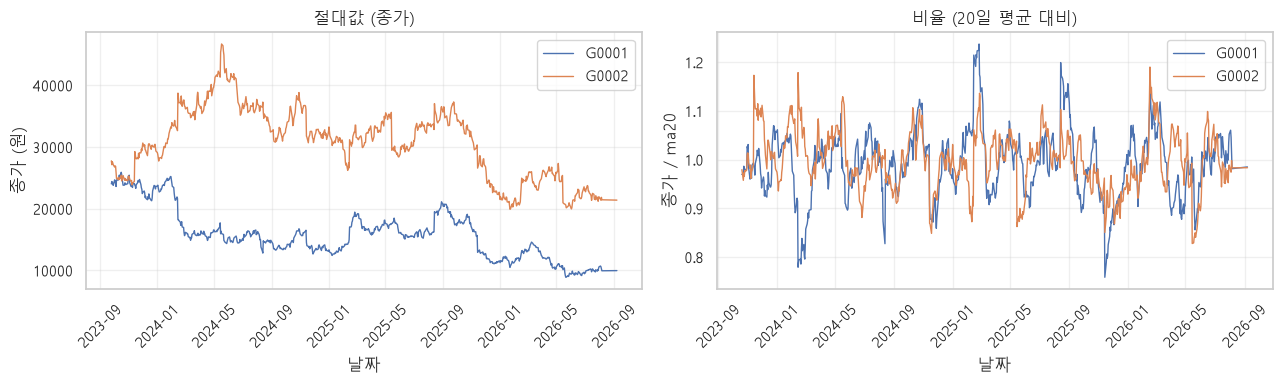

In [12]:
# 두 종목만 골라서 비교
two = full[full["code"].isin(["G0001", "G0002"])].copy()

# 20일 이동 평균과 비율
two["ma20"] = two.groupby("code")["close"].transform(lambda s: s.rolling(20).mean())
two["ma20_ratio"] = two["close"] / two["ma20"]

# 그래프
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for code, g in two.groupby("code"):
    axes[0].plot(g["date"], g["close"], label=code, lw=1)
    axes[1].plot(g["date"], g["ma20_ratio"], label=code, lw=1)

axes[0].set(title="절대값 (종가)", xlabel="날짜", ylabel="종가 (원)")
axes[1].set(title="비율 (20일 평균 대비)", xlabel="날짜", ylabel="종가 / ma20")

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

**절대값보다 비율이 대체로 파악하기가 좋음!**
왼쪽 그래프는 두 종목의 가격대가 다르기 때문에, 나란히 두고 비교하기가 어려움.\
오른쪽 그래프는 표시된 값이 1.0 근처에서 차이를 보여주고 있음. 변화량에 대해 비교하기가 비교적 수월함!

> 어떤 파생변수가 유효한지는 그 분야에 대해 **도메인** 지식이 필요함! (판단할 수가 있음)

---
## 데이터 누수
**데이터 누수**: 학습 시점에 알 수 없는 정보가 피처에 섞여 들어가는 것.

### 유형
- 미래정보 : 오늘 종가로 오늘 피처를 만든 경우
- 정답누출 : 정답에서 파생된 변수를 피처에 넣음
- 전처리 누수 : 전체 데이터로 스케일링 한 후에 분할


> **문제 재설정**\
"당일 장이 종료되기 전에, 오를지 예측"

당일의 종가는 아직 알 수 없음! 피처는 전일까지의 정보여야 함!

- 피처 : 당일 종가 기준 이동 평균 (shift())
=> 당일 종가는 끝나야 알 수 있음.  

In [14]:
정상 = build_dataset(shift_features=True)
누수 = build_dataset(shift_features=False)

cols = ["date", "close", "ret_1d", "target_ret", "target_up"]

def display_data(data):
    v = data[data["code"] == "G0001"][cols].head(4).reset_index(drop=True)

    nums = ["ret_1d", "target_ret"]
    v[nums] = v[nums].round(5)

    return v.to_string(index=False)

print("1. shift 적용 (정상)")
print(display_data(정상))
print()
print("2. shift 미적용 (누수)")
print(display_data(누수))

1. shift 적용 (정상)
      date  close   ret_1d  target_ret  target_up
2023-10-24  24193  0.00092     0.01557          1
2023-10-25  23984  0.01557    -0.00864          0
2023-10-26  23913 -0.00864    -0.00296          0
2023-10-27  23977 -0.00296     0.00268          1

2. shift 미적용 (누수)
      date  close   ret_1d  target_ret  target_up
2023-10-23  23822  0.00092     0.00092          1
2023-10-24  24193  0.01557     0.01557          1
2023-10-25  23984 -0.00864    -0.00864          0
2023-10-26  23913 -0.00296    -0.00296          0


**누수 데이터 확인하면**  
ret_1d 와 target_ret 의 값이 완전히 동일함.\
ret_1d(오늘의 수익률)와 target_ret(오늘의 수익률)이 같은 계산이기 때문에, 즉 정답을 피처로 준 것과 동일함!

In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score

결과 = []

for data, label in [(정상, "정상(shift 적용)"), (누수, "누수(shift 미적용)")]:
    tr_, te_, _ = time_split(data)

    tr_ = tr_.sample(15000, random_state=SEED)
    te_ = te_.sample(4000, random_state=SEED)

    m = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=SEED, n_jobs=-1)

    m.fit(tr_[FEATURES], tr_["target_up"])              # 학습

    pred = m.predict(te_[FEATURES])                     # 예측 (0/1)
    proba = m.predict_proba(te_[FEATURES])[:, 1]        # 예측 (상승 확률)

    결과.append({
        "구분": label,
        "정확도": accuracy_score(te_["target_up"], pred),
        "AUC": roc_auc_score(te_["target_up"], proba),
    })

print(pd.DataFrame(결과).round(4).to_string(index=False))

           구분    정확도    AUC
 정상(shift 적용) 0.4992 0.4943
누수(shift 미적용) 0.9992 0.9997


**정확도가 99% 이상 나올 수 있으나**
실제로는 좋은 모델이 아님! 오늘의 종가를 미리 입력으로 줄 수 없음!!\

**누수를 의심해야 하는 경우**
- 성능이 기대보다 과하게 좋은 경우 
- 특정 피처 하나의 중요도가 압도적으로 높을 경우
- 학습과 테스트의 성능 차이가 거의 없는 경우

누수 시에 피처를 전부 시각화해보면 특정 피처와  정답이 동일하게 움직일 수 있음.\
-> 특정 피처의 중요도가 압도적인 경우 (누수)

---
### 피처
: 모델에 영향을 주는 변수(데이터)

###  스케일링
: 데이터 표준화 (크기를 맞춰주는 작업) => fit_transform 은 학습 데이터만 사용

### 인코딩 
: 문자를 숫자로 변환 (순서 없는 범주에는 LabelEncoder 사용 X)

### 파생변수 
: 기존 데이터로부터 만들어진 변수(데이터). 절대값 보다는 비율.

### 데이터 누수
: 학습 시점에 잘못된 데이터가 섞이는 현상. 성능이 너무 좋으면 의심하자!

### 파이프라인(Pipline)
**순서/흐름** 
1. 결측, 이상치 처리 (전처리)
2. 파생 변수 생성 
3. 데이터 분리 (학습용,테스트)
4. 스케일링, 인코딩 준비 -> fit(학습데이터)
5. 변환 -> transform(학습데이터), transeform(테스트데이터)\
...\
...\
...